In [27]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [28]:
train_df = pd.read_csv("F:/Jupyter Projects/Phitron AL ML/Dataset/sign_mnist_train.csv")
train_df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,156,158,160,163,165,159,166,168,170,170,171,171,171,172,171,171,170,170,169,111,121,129,135,141,144,148,151,154,157,160,...,205,206,206,207,207,206,206,204,205,204,203,202,142,151,160,172,196,188,188,190,135,96,86,77,77,79,176,205,207,207,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,157,158,156,154,154,153,152,151,149,149,148,147,146,144,142,143,138,92,108,158,159,159,159,160,160,160,160,160,160,160,...,100,78,120,157,168,107,99,121,133,97,95,120,135,116,95,79,69,86,139,173,200,185,175,198,124,118,94,140,133,84,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,186,185,185,185,184,184,184,181,181,179,179,179,178,178,109,52,66,77,83,188,189,189,188,188,189,188,188,188,188,187,...,203,204,203,201,200,200,199,198,196,195,194,193,198,166,132,114,89,74,79,77,74,78,132,188,210,209,206,205,204,203,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,211,209,207,208,207,206,203,202,201,200,198,197,195,192,197,171,51,52,54,212,213,215,215,212,212,213,212,212,211,211,...,247,242,233,231,230,229,227,225,223,221,220,216,58,51,49,50,57,60,17,15,18,17,19,1,159,255,237,239,237,236,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,186,188,189,189,190,191,189,190,190,187,190,192,193,191,191,192,192,194,194,166,169,172,174,177,180,182,185,186,187,190,...,90,77,88,117,123,127,129,134,145,152,156,179,105,106,105,104,104,104,175,199,178,152,136,130,136,150,118,92,85,76,92,105,105,108,133,163,157,163,164,179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27450,13,189,189,190,190,192,193,193,193,193,194,193,193,194,194,195,195,196,194,195,196,196,197,196,197,197,196,195,195,189,190,192,192,193,194,195,196,196,196,193,...,115,92,132,173,118,84,53,135,253,213,219,208,82,82,84,85,85,87,84,87,78,113,216,189,172,175,155,131,116,93,132,165,99,77,52,200,234,200,222,225
27451,23,151,154,157,158,160,161,163,164,166,167,169,169,169,169,169,169,169,169,169,167,167,167,166,165,164,164,163,162,153,156,159,160,162,163,164,165,167,169,172,...,199,200,199,199,198,199,198,197,196,195,195,194,66,67,65,62,61,41,32,37,33,30,28,38,187,202,199,199,199,199,198,198,198,198,198,196,195,195,195,194
27452,18,174,174,174,174,174,175,175,174,173,173,173,172,171,171,171,170,169,168,166,166,165,165,163,162,161,160,158,156,178,178,177,176,177,177,177,176,176,176,175,...,110,85,90,166,205,207,205,203,202,201,200,198,217,217,217,218,218,211,203,200,189,171,157,145,136,129,128,125,101,77,121,196,209,208,206,204,203,202,200,200
27453,17,177,181,184,185,187,189,190,191,191,190,191,193,192,191,191,191,191,190,190,189,187,186,184,183,182,181,179,177,179,182,185,187,189,190,192,192,192,192,194,...,190,173,140,80,28,60,70,61,61,78,100,86,136,135,135,135,132,132,136,136,137,144,103,120,197,200,195,196,170,149,119,56,27,58,102,79,47,64,87,93


In [29]:
test_df = pd.read_csv("F:/Jupyter Projects/Phitron AL ML/Dataset/sign_mnist_test.csv")
test_df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,152,152,152,152,152,153,153,151,152,152,153,152,152,151,151,150,150,150,149,150,150,150,152,152,151,152,152,152,152,152,...,131,134,144,147,125,87,87,103,107,110,116,113,75,74,74,74,76,74,82,134,168,155,146,137,145,146,149,135,124,125,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,138,137,137,138,138,139,137,142,140,138,139,137,137,136,135,134,133,134,132,129,132,134,135,135,137,139,139,139,140,141,...,114,112,89,48,133,194,182,185,184,184,182,181,172,174,177,178,178,179,181,183,187,175,165,154,118,107,100,75,96,83,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,152,157,163,168,171,182,172,175,185,183,184,185,185,185,183,183,182,181,178,86,88,93,96,108,125,137,145,149,154,160,...,145,123,78,162,239,227,229,226,226,225,224,222,89,91,94,111,136,154,167,184,125,3,166,225,195,188,172,185,161,122,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,209,208,207,207,209,208,210,210,207,209,209,208,209,210,209,207,208,209,207,206,208,209,208,208,210,211,210,211,209,209,...,85,80,84,151,238,255,255,250,237,245,250,232,103,101,102,103,95,208,231,227,209,190,179,182,152,150,159,119,83,63,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,203,204,204,204,203,202,198,216,217,135,181,200,195,194,193,190,189,187,185,190,194,196,197,200,202,204,206,207,207,206,...,93,52,24,53,63,33,41,51,48,45,49,55,149,150,150,148,147,151,124,82,84,81,69,81,111,103,84,75,53,28,26,40,64,48,29,46,49,46,46,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7167,1,135,119,108,102,105,99,61,103,121,133,143,148,156,160,162,164,168,171,173,175,178,179,181,182,184,185,185,186,137,116,111,101,110,92,66,108,124,132,155,...,147,132,115,112,117,118,112,153,189,178,173,166,140,121,157,125,93,99,100,101,104,100,118,167,154,141,136,139,135,125,108,112,116,114,118,180,184,176,167,163
7168,12,157,159,161,164,166,166,171,174,175,176,176,176,178,176,176,178,177,176,178,178,177,176,176,176,174,174,173,173,159,163,164,166,168,169,173,175,177,178,177,...,90,78,191,215,212,214,212,209,209,208,208,207,189,192,196,199,191,208,230,201,197,185,184,187,169,136,131,107,69,127,213,213,213,214,213,211,210,210,209,208
7169,2,190,191,190,191,190,190,192,192,191,192,193,192,191,192,191,191,192,189,189,189,188,188,188,187,186,185,184,183,193,193,193,193,193,193,194,194,193,195,195,...,215,215,215,214,213,213,212,212,210,209,208,207,215,215,207,207,208,207,203,196,170,99,92,92,89,155,213,216,216,216,216,215,213,214,214,213,210,211,209,208
7170,4,201,205,208,209,214,216,218,223,226,229,234,233,233,237,237,237,240,241,238,240,240,242,243,241,239,239,239,239,206,209,212,215,218,220,223,226,227,229,236,...,168,173,128,127,255,255,255,255,159,99,80,77,255,255,255,255,255,255,231,255,255,255,255,255,249,231,188,164,169,176,112,169,255,255,237,113,91,67,70,63


In [30]:
train_df.shape

(27455, 785)

In [31]:
test_df.shape

(7172, 785)

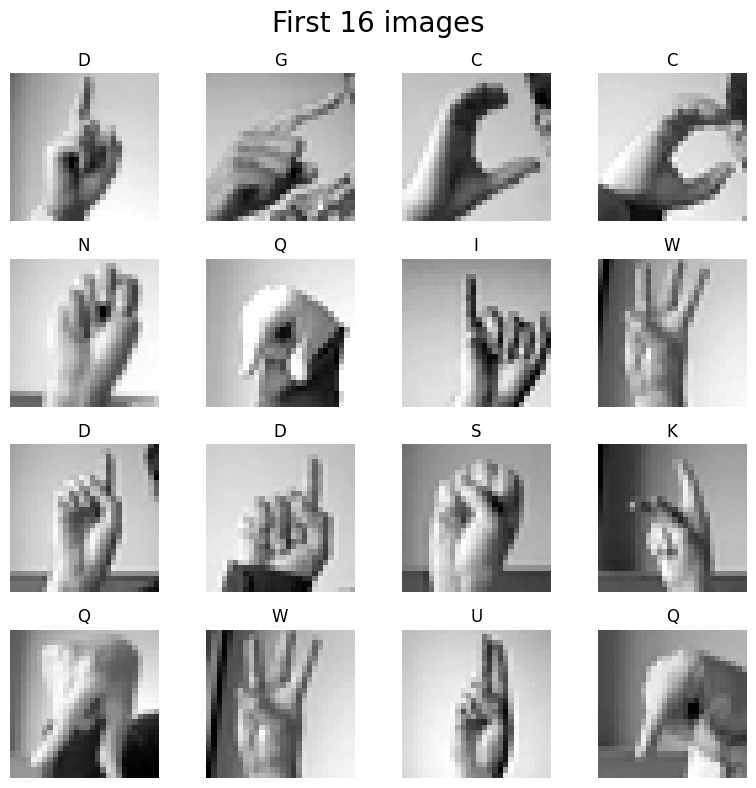

In [32]:
def raw_to_letter(y):
    return chr(ord("A") + y)

fig, axes = plt.subplots(4, 4, figsize=(8,8))
fig.suptitle("First 16 images", fontsize=20)

for i, ax in enumerate(axes.flat):
    row=train_df.iloc[i]
    img=row.iloc[1:].values.astype(np.float32).reshape(28,28)
    ax.imshow(img, cmap="gray")
    ax.set_title(raw_to_letter(row["label"]))
    ax.axis("off")

plt.tight_layout()
plt.show()

In [33]:
def remap_label(y):
    y=int(y)
    if y>9:
        y=y-1
    return y

LETTERS = [chr(ord("A") + i) for i in range(26) if i not in (9, 25)]
idx_to_letter = {i: ch for i, ch in enumerate(LETTERS)}

def remap_frame(df):
    out = df.copy()
    out["label"] = out["label"].map(remap_label)
    return out

print("before:", sorted(train_df["label"].unique())[:12], "...")

train_df = remap_frame(train_df)
test_df = remap_frame(test_df)


print("after: ", sorted(train_df["label"].unique()))

before: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12] ...
after:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [34]:
assert train_df["label"].nunique() == 24

In [35]:
assert set(train_df["label"].unique()) == set(range(24))

In [36]:
SAMPLES_PER_CLASS = 100


def subset_per_class(df, n, seed=SEED):
    parts = []

    for _, group in df.groupby("label"):
        take = min(n, len(group))
        parts.append(group.sample(n=take, random_state=seed))

    return (
        pd.concat(parts)
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )


all_df = pd.concat([train_df, test_df], ignore_index=True)

small_df = subset_per_class(all_df, SAMPLES_PER_CLASS)

X = small_df.iloc[:, 1:].values

y = small_df.iloc[:, 0].values.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(
    f"subset: {len(small_df)} "
    f"({SAMPLES_PER_CLASS} x 24 = {SAMPLES_PER_CLASS * 24})"
)

print(f"train: {len(X_train)}   test: {len(X_test)}")

print("stratify=y so we did not dump all the A's into train by accident.")

subset: 2400 (100 x 24 = 2400)
train: 1920   test: 480
stratify=y so we did not dump all the A's into train by accident.


In [37]:
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print("X_train", X_train.shape, X_train.min(), X_train.max())
print("y_train", y_train.shape, y_train.min(), y_train.max())
print("X_test ", X_test.shape)
print("one row is 784 floats. a picture, legally speaking.")


class CustomDataset(Dataset):

    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]


train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

x0, y0 = train_dataset[0]

print(
    "one sample →",
    tuple(x0.shape),
    " letter",
    idx_to_letter[int(y0)]
)

print("len train/test:", len(train_dataset), len(test_dataset))


BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


xb, yb = next(iter(train_loader))

print("batch X:", tuple(xb.shape), " → [B, 784]")
print("batch y:", tuple(yb.shape), " → [B]")

print(
    "letters:",
    [idx_to_letter[int(i)] for i in yb[:8]],
    "..."
)

print(
    "train batches:",
    len(train_loader),
    " test batches:",
    len(test_loader)
)

X_train (1920, 784) 0.0 1.0
y_train (1920,) 0 23
X_test  (480, 784)
one row is 784 floats. a picture, legally speaking.
one sample → (784,)  letter B
len train/test: 1920 480
batch X: (32, 784)  → [B, 784]
batch y: (32,)  → [B]
letters: ['T', 'S', 'R', 'X', 'I', 'H', 'Y', 'K'] ...
train batches: 60  test batches: 15


MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=24, bias=True)
  )
)
dummy in:  (2, 784)
logits out: (2, 24)
Epoch: 1 , Loss: 3.1798
Epoch: 2 , Loss: 3.1577
Epoch: 3 , Loss: 3.0621
Epoch: 4 , Loss: 2.9272
Epoch: 5 , Loss: 2.7775
Epoch: 6 , Loss: 2.6677
Epoch: 7 , Loss: 2.5934
Epoch: 8 , Loss: 2.5050
Epoch: 9 , Loss: 2.3900
Epoch: 10 , Loss: 2.3101
Epoch: 11 , Loss: 2.3087
Epoch: 12 , Loss: 2.1674
Epoch: 13 , Loss: 2.1240
Epoch: 14 , Loss: 2.0824
Epoch: 15 , Loss: 2.0936
Epoch: 16 , Loss: 1.9273
Epoch: 17 , Loss: 1.7652
Epoch: 18 , Loss: 1.8437
Epoch: 19 , Loss: 1.8229
Epoch: 20 , Loss: 1.6692

done. if you expected fluent ASL, that is a different course.


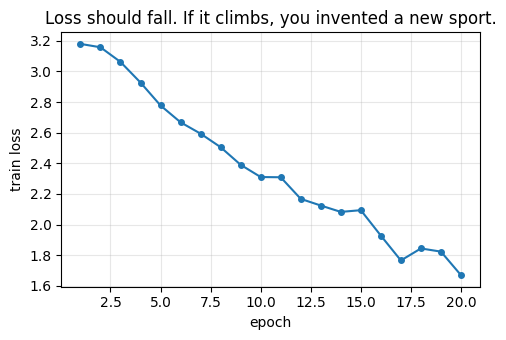

In [41]:
class MyNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.model(x)


num_features = X_train.shape[1]
num_classes = 24

model = MyNN(num_features, num_classes)

print(model)

dummy = torch.randn(2, num_features)

with torch.no_grad():
    logits = model(dummy)

print("dummy in: ", tuple(dummy.shape))
print("logits out:", tuple(logits.shape))


# 9. Train

learning_rate = 0.1
epochs = 20

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

train_losses = []

for epoch in range(epochs):
    model.train()
    total_epoch_loss = 0.0

    for batch_features, batch_labels in train_loader:
        batch_features = batch_features
        batch_labels = batch_labels

        optimizer.zero_grad()

        outputs = model(batch_features)

        loss = criterion(outputs, batch_labels)

        loss.backward()

        optimizer.step()

        total_epoch_loss += loss.item()

    avg_loss = total_epoch_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(f"Epoch: {epoch + 1} , Loss: {avg_loss:.4f}")

print("\ndone. if you expected fluent ASL, that is a different course.")


# Loss curve

plt.figure(figsize=(5, 3.5))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    marker="o",
    markersize=4
)

plt.xlabel("epoch")
plt.ylabel("train loss")
plt.title("Loss should fall. If it climbs, you invented a new sport.")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

In [43]:
def accuracy(loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for batch_features, batch_labels in loader:

            batch_features = batch_features
            batch_labels = batch_labels

            predicted = model(batch_features).argmax(dim=1)

            total += batch_labels.shape[0]

            correct += (predicted == batch_labels).sum().item()

    return correct / total


test_acc = accuracy(test_loader)

train_acc = accuracy(train_loader)

chance = 1.0 / num_classes

print(
    f"test accuracy:  {test_acc:.3f}   "
    f"({100 * test_acc:.1f}%)"
)

print(
    f"train accuracy: {train_acc:.3f}   "
    f"({100 * train_acc:.1f}%)"
)

print(
    f"random guessing: {chance:.3f}   "
    f"({100 * chance:.1f}%)"
)

test accuracy:  0.375   (37.5%)
train accuracy: 0.445   (44.5%)
random guessing: 0.042   (4.2%)


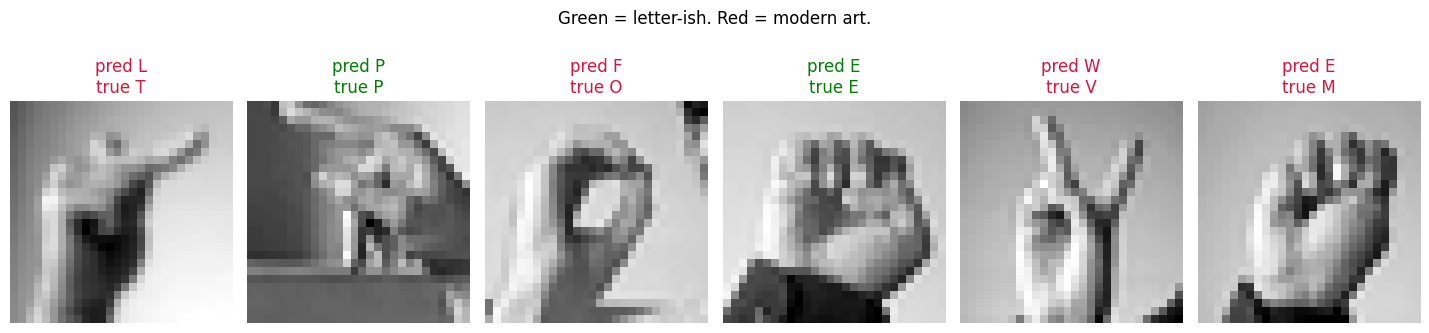

In [45]:
N_SHOW = 6

vis_x, vis_y = next(iter(test_loader))

vis_x = vis_x[:N_SHOW]
vis_y = vis_y[:N_SHOW]

model.eval()

with torch.no_grad():

    preds = (
        model(vis_x)
        .argmax(dim=1)
        .cpu()
    )


fig, axes = plt.subplots(
    1,
    N_SHOW,
    figsize=(2.4 * N_SHOW, 3.2)
)

for ax, flat, true_y, pred_y in zip(
    axes,
    vis_x,
    vis_y,
    preds
):

    ax.imshow(
        flat.reshape(28, 28),
        cmap="gray"
    )

    true_ch = idx_to_letter[int(true_y)]

    pred_ch = idx_to_letter[int(pred_y)]

    ok = pred_y == true_y

    ax.set_title(
        f"pred {pred_ch}\ntrue {true_ch}",
        color=("green" if ok else "crimson")
    )

    ax.axis("off")


plt.suptitle(
    "Green = letter-ish. Red = modern art.",
    y=1.08
)

plt.tight_layout()

plt.show()

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

In [47]:
train_df = pd.read_csv(
    "F:/Jupyter Projects/Phitron AL ML/Dataset/sign_mnist_train.csv"
)

test_df = pd.read_csv(
    "F:/Jupyter Projects/Phitron AL ML/Dataset/sign_mnist_test.csv"
)

In [48]:
df = pd.concat([train_df, test_df], ignore_index=True)

In [49]:
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,156,158,160,163,165,159,166,168,170,170,171,171,171,172,171,171,170,170,169,111,121,129,135,141,144,148,151,154,157,160,...,205,206,206,207,207,206,206,204,205,204,203,202,142,151,160,172,196,188,188,190,135,96,86,77,77,79,176,205,207,207,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,157,158,156,154,154,153,152,151,149,149,148,147,146,144,142,143,138,92,108,158,159,159,159,160,160,160,160,160,160,160,...,100,78,120,157,168,107,99,121,133,97,95,120,135,116,95,79,69,86,139,173,200,185,175,198,124,118,94,140,133,84,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,186,185,185,185,184,184,184,181,181,179,179,179,178,178,109,52,66,77,83,188,189,189,188,188,189,188,188,188,188,187,...,203,204,203,201,200,200,199,198,196,195,194,193,198,166,132,114,89,74,79,77,74,78,132,188,210,209,206,205,204,203,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,211,209,207,208,207,206,203,202,201,200,198,197,195,192,197,171,51,52,54,212,213,215,215,212,212,213,212,212,211,211,...,247,242,233,231,230,229,227,225,223,221,220,216,58,51,49,50,57,60,17,15,18,17,19,1,159,255,237,239,237,236,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,186,188,189,189,190,191,189,190,190,187,190,192,193,191,191,192,192,194,194,166,169,172,174,177,180,182,185,186,187,190,...,90,77,88,117,123,127,129,134,145,152,156,179,105,106,105,104,104,104,175,199,178,152,136,130,136,150,118,92,85,76,92,105,105,108,133,163,157,163,164,179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34622,1,135,119,108,102,105,99,61,103,121,133,143,148,156,160,162,164,168,171,173,175,178,179,181,182,184,185,185,186,137,116,111,101,110,92,66,108,124,132,155,...,147,132,115,112,117,118,112,153,189,178,173,166,140,121,157,125,93,99,100,101,104,100,118,167,154,141,136,139,135,125,108,112,116,114,118,180,184,176,167,163
34623,12,157,159,161,164,166,166,171,174,175,176,176,176,178,176,176,178,177,176,178,178,177,176,176,176,174,174,173,173,159,163,164,166,168,169,173,175,177,178,177,...,90,78,191,215,212,214,212,209,209,208,208,207,189,192,196,199,191,208,230,201,197,185,184,187,169,136,131,107,69,127,213,213,213,214,213,211,210,210,209,208
34624,2,190,191,190,191,190,190,192,192,191,192,193,192,191,192,191,191,192,189,189,189,188,188,188,187,186,185,184,183,193,193,193,193,193,193,194,194,193,195,195,...,215,215,215,214,213,213,212,212,210,209,208,207,215,215,207,207,208,207,203,196,170,99,92,92,89,155,213,216,216,216,216,215,213,214,214,213,210,211,209,208
34625,4,201,205,208,209,214,216,218,223,226,229,234,233,233,237,237,237,240,241,238,240,240,242,243,241,239,239,239,239,206,209,212,215,218,220,223,226,227,229,236,...,168,173,128,127,255,255,255,255,159,99,80,77,255,255,255,255,255,255,231,255,255,255,255,255,249,231,188,164,169,176,112,169,255,255,237,113,91,67,70,63


In [50]:
df["label"] = df["label"].apply(
    lambda x: x - 1 if x > 9 else x
)

In [51]:
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,156,158,160,163,165,159,166,168,170,170,171,171,171,172,171,171,170,170,169,111,121,129,135,141,144,148,151,154,157,160,...,205,206,206,207,207,206,206,204,205,204,203,202,142,151,160,172,196,188,188,190,135,96,86,77,77,79,176,205,207,207,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,157,158,156,154,154,153,152,151,149,149,148,147,146,144,142,143,138,92,108,158,159,159,159,160,160,160,160,160,160,160,...,100,78,120,157,168,107,99,121,133,97,95,120,135,116,95,79,69,86,139,173,200,185,175,198,124,118,94,140,133,84,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,186,185,185,185,184,184,184,181,181,179,179,179,178,178,109,52,66,77,83,188,189,189,188,188,189,188,188,188,188,187,...,203,204,203,201,200,200,199,198,196,195,194,193,198,166,132,114,89,74,79,77,74,78,132,188,210,209,206,205,204,203,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,211,209,207,208,207,206,203,202,201,200,198,197,195,192,197,171,51,52,54,212,213,215,215,212,212,213,212,212,211,211,...,247,242,233,231,230,229,227,225,223,221,220,216,58,51,49,50,57,60,17,15,18,17,19,1,159,255,237,239,237,236,235,234,233,231,230,226,225,222,229,163
4,12,164,167,170,172,176,179,180,184,185,186,188,189,189,190,191,189,190,190,187,190,192,193,191,191,192,192,194,194,166,169,172,174,177,180,182,185,186,187,190,...,90,77,88,117,123,127,129,134,145,152,156,179,105,106,105,104,104,104,175,199,178,152,136,130,136,150,118,92,85,76,92,105,105,108,133,163,157,163,164,179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34622,1,135,119,108,102,105,99,61,103,121,133,143,148,156,160,162,164,168,171,173,175,178,179,181,182,184,185,185,186,137,116,111,101,110,92,66,108,124,132,155,...,147,132,115,112,117,118,112,153,189,178,173,166,140,121,157,125,93,99,100,101,104,100,118,167,154,141,136,139,135,125,108,112,116,114,118,180,184,176,167,163
34623,11,157,159,161,164,166,166,171,174,175,176,176,176,178,176,176,178,177,176,178,178,177,176,176,176,174,174,173,173,159,163,164,166,168,169,173,175,177,178,177,...,90,78,191,215,212,214,212,209,209,208,208,207,189,192,196,199,191,208,230,201,197,185,184,187,169,136,131,107,69,127,213,213,213,214,213,211,210,210,209,208
34624,2,190,191,190,191,190,190,192,192,191,192,193,192,191,192,191,191,192,189,189,189,188,188,188,187,186,185,184,183,193,193,193,193,193,193,194,194,193,195,195,...,215,215,215,214,213,213,212,212,210,209,208,207,215,215,207,207,208,207,203,196,170,99,92,92,89,155,213,216,216,216,216,215,213,214,214,213,210,211,209,208
34625,4,201,205,208,209,214,216,218,223,226,229,234,233,233,237,237,237,240,241,238,240,240,242,243,241,239,239,239,239,206,209,212,215,218,220,223,226,227,229,236,...,168,173,128,127,255,255,255,255,159,99,80,77,255,255,255,255,255,255,231,255,255,255,255,255,249,231,188,164,169,176,112,169,255,255,237,113,91,67,70,63


In [52]:
X = df.iloc[:, 1:].values.astype(np.float32)
y = df["label"].values.astype(np.int64)

In [53]:
X

array([[107., 118., 127., ..., 204., 203., 202.],
       [155., 157., 156., ..., 103., 135., 149.],
       [187., 188., 188., ..., 195., 194., 195.],
       ...,
       [190., 191., 190., ..., 211., 209., 208.],
       [201., 205., 208., ...,  67.,  70.,  63.],
       [173., 174., 173., ..., 195., 193., 192.]], dtype=float32)

In [54]:
y

array([3, 6, 2, ..., 2, 4, 2], dtype=int64)

In [55]:
X = X / 255.0

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [57]:
print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (27701, 784)
Test : (6926, 784)


In [58]:
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)


In [59]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [60]:
class MyNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 24)
        )

    def forward(self, x):
        return self.model(x)


model = MyNN()

print(model)

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=24, bias=True)
  )
)


In [61]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [62]:
epochs = 15

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Loss: {average_loss:.4f}"
    )

Epoch 1/15 - Loss: 2.1584
Epoch 2/15 - Loss: 1.2843
Epoch 3/15 - Loss: 0.9189
Epoch 4/15 - Loss: 0.6995
Epoch 5/15 - Loss: 0.5175
Epoch 6/15 - Loss: 0.3964
Epoch 7/15 - Loss: 0.3035
Epoch 8/15 - Loss: 0.2209
Epoch 9/15 - Loss: 0.1750
Epoch 10/15 - Loss: 0.1234
Epoch 11/15 - Loss: 0.0903
Epoch 12/15 - Loss: 0.1064
Epoch 13/15 - Loss: 0.0718
Epoch 14/15 - Loss: 0.0842
Epoch 15/15 - Loss: 0.0403


In [63]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)


accuracy = correct / total

print(f"\nTest Accuracy: {accuracy * 100:.2f}%")


Test Accuracy: 99.54%
